<a href="https://colab.research.google.com/github/gabriela-vemieiro/notes_curso_analise_exploracao_dados/blob/main/Lab_Engenharia_de_Atributos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Engenharia de Atributos**


Uma parte crítica de um projeto de Machine Learning bem-sucedido é criar um bom conjunto de atributos (features) para treinamento. Esse processo é chamado de engenharia de atributos e envolve três etapas: transformação de atributos (transformar os atributos originais), seleção de atributos (selecionar os atributos mais úteis para o treinamento) e extração de atributos (combinar atributos existentes para produzir novos mais úteis). Neste notebook, exploraremos diferentes ferramentas de Engenharia de Atributos.


## Objetivos


Após concluir este laboratório, você será capaz de:


*   Compreender os tipos de Engenharia de Atributos
    *   Transformação de Atributos
        *   Lidando com Variáveis Categóricas
            *   One Hot Encoding
            *   Label Encoding
        *   Transformações de Data e Hora
    *   Seleção de Atributos
    *   Extração de Atributos usando Análise de Componentes Principais (PCA)


***


## **Configuração**


Para este laboratório, usaremos as seguintes bibliotecas:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork30654641-2022-01-01) para gerenciar os dados.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork30654641-2022-01-01) para operações matemáticas.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork30654641-2022-01-01) para visualizar os dados.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork30654641-2022-01-01) para visualizar os dados.
*   [`plotly.express`](https://plotly.com/python/plotly-express/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork30654641-2022-01-01) para visualizar os dados.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork30654641-2022-01-01) para funções relacionadas a machine learning e pipelines de machine learning.


## **Instalação das Bibliotecas Necessárias**


Os seguintes módulos necessários já estão pré-instalados no ambiente Skills Network Labs. No entanto, se você executar os comandos deste notebook em um ambiente Jupyter diferente (por exemplo, Watson Studio ou Anaconda), precisará instalar essas bibliotecas removendo o sinal `#` antes de `!mamba` na célula de código abaixo.


In [ ]:
# Todas as bibliotecas necessárias para este laboratório estão listadas abaixo. As bibliotecas pré-instaladas no Skills Network Labs estão comentadas.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Observação: se o seu ambiente não suportar "!mamba install", use "!pip install"

In [ ]:
!mamba install -qy openpyxl

In [ ]:
# Suprimir avisos do uso de versões mais antigas do sklearn:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## **Lendo e compreendendo nossos dados**


Para este laboratório, usaremos o arquivo airlines_data.xlsx, hospedado no IBM Cloud Object Storage. Este conjunto de dados contém os preços de passagens aéreas de várias companhias aéreas entre os meses de março e junho de 2019 e entre várias cidades. Esse dataset é frequentemente usado para análise de previsão dos preços de voos, que são influenciados por vários fatores, como nome da companhia aérea, data da viagem, rota, horários de partida e chegada, a origem e o destino da viagem, duração e outros parâmetros.

Neste notebook, usaremos o conjunto de dados da companhia aérea para realizar engenharia de atributos em algumas de suas variáveis independentes.


Vamos começar lendo os dados em um data frame *pandas* e examinando as primeiras 5 linhas usando o método `head()`.


In [2]:
data = pd.read_excel('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0232EN-SkillsNetwork/asset/airlines_data.xlsx')
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


Usando a função `info()`, daremos uma olhada nos tipos de dados que nosso conjunto de dados contém.


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


Como vemos na saída acima, temos principalmente tipos de dados objeto, exceto pela coluna 'price', que é um inteiro.


A função `describe()` fornece informações estatísticas sobre as variáveis numéricas. No nosso caso, é a variável 'price'.


In [4]:
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


Em seguida, verificaremos se há valores nulos.


In [5]:
data.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


Agora que encontramos alguns pontos nulos, precisamos removê-los do nosso conjunto de dados ou preenchê-los com outra coisa. Neste caso, usaremos `fillna()` e `method='ffill'`, que preenche o último valor não nulo observado para frente até que outro valor não nulo seja encontrado.


In [6]:
data = data.fillna(method='ffill')

/tmp/ipykernel_8434/917065080.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


## **Transformação de Atributos**


Transformação de Atributos significa transformar nossos atributos em funções dos atributos originais. Por exemplo, codificação de atributos (encoding), escalonamento (scaling) e discretização (o processo de transformar variáveis contínuas em forma discreta, criando compartimentos ou intervalos) são as formas mais comuns de transformação de dados.


### **Lidando com Variáveis Categóricas**


Variáveis categóricas representam dados qualitativos sem nenhum significado matemático inerente aparente. Portanto, para qualquer análise de machine learning, todos os dados categóricos devem ser transformados em tipos de dados numéricos. Primeiro, começaremos com a coluna 'Airline', pois ela contém valores categóricos. Usaremos o método `unique()` para obter todas as categorias desta coluna.


In [7]:
data['Airline'].unique().tolist()

['IndiGo',
 'Air India',
 'Jet Airways',
 'SpiceJet',
 'Multiple carriers',
 'GoAir',
 'Vistara',
 'Air Asia',
 'Vistara Premium economy',
 'Jet Airways Business',
 'Multiple carriers Premium economy',
 'Trujet']

Da lista acima, notamos que alguns nomes de companhias aéreas estão se repetindo. Por exemplo, 'Jet Airways' e 'Jet Airways Business'. Isso significa que algumas das companhias aéreas estão subdivididas em partes separadas. Vamos combinar essas companhias aéreas de 'duas partes' para tornar nossos atributos categóricos mais consistentes com o resto das variáveis.

Aqui, usaremos a função *numpy* `where()` para localizar e combinar as duas categorias.


In [8]:
data['Airline'] = np.where(data['Airline']=='Vistara Premium economy', 'Vistara', data['Airline'])
data['Airline'] = np.where(data['Airline']=='Jet Airways Business', 'Jet Airways', data['Airline'])

## Exercício 1

Neste exercício, use a função `np.where()` para combinar as categorias 'Multiple carriers Premium economy' e 'Multiple carriers', conforme mostrado no código acima. Imprima a lista recém-criada usando as funções `unique().tolist()`.


In [12]:
data['Airline'] = np.where(data['Airline']=='Multiple carriers Premium economy', 'Multiple carriers', data['Airline'])
data['Airline'].unique().tolist()

['IndiGo',
 'Air India',
 'Jet Airways',
 'SpiceJet',
 'Multiple carriers',
 'GoAir',
 'Vistara',
 'Air Asia',
 'Trujet']

#### **One Hot Encoding**


Agora, para serem reconhecidas por algoritmos de machine learning, nossas variáveis categóricas devem ser convertidas em numéricas. Uma maneira de fazer isso é através de *one hot encoding*. Para saber mais sobre esse processo, visite esta [documentação](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork30654641-2022-01-01).

Usaremos o método `get_dummies()` para fazer essa transformação. Na próxima célula, transformaremos 'Airline', 'Source' e 'Destination' em suas respectivas variáveis numéricas. Colocaremos todos os dados transformados em um data frame 'data1'.


In [13]:
data1 = pd.get_dummies(data=data, columns = ['Airline', 'Source', 'Destination'])

In [14]:
data1.head()

,Date_of_Journey,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Airline_Air Asia,Airline_Air India,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,24/03/2019,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1/05/2019,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,False,True,...,False,False,True,False,True,False,False,False,False,False
2,9/06/2019,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,False,False,...,False,True,False,False,False,True,False,False,False,False
3,12/05/2019,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,False,False,...,False,False,True,False,True,False,False,False,False,False
4,01/03/2019,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,False,False,...,False,False,False,False,False,False,False,False,False,True


Abaixo, compararemos nosso data frame original com o transformado.


In [15]:
data.shape

(10683, 11)

In [16]:
data1.shape

(10683, 28)

Como podemos ver, passamos de 11 atributos originais em nosso dataset para 38. Isso ocorre porque a abordagem `get_dummies()` do *Pandas*, quando aplicada a uma coluna com diferentes categorias (por exemplo, diferentes companhias aéreas), produzirá uma nova coluna (variável) para cada valor categórico único (para cada companhia aérea única). Ela colocará um na coluna correspondente ao valor categórico presente para aquela observação.


## Exercício 2

Neste exercício, use `value_counts()` para determinar a distribuição dos valores do parâmetro 'Total_Stops'.


In [17]:
data["Total_Stops"].value_counts()

,count
Total_Stops,
1 stop,5625
non-stop,3492
2 stops,1520
3 stops,45
4 stops,1


#### **Label Encoding**


Como 'Total_Stops' é originalmente um tipo de dado categórico, também precisamos convertê-lo em numérico. Para isso, podemos realizar um *label encoding*, onde os valores são atribuídos manualmente às chaves correspondentes, como "0" para "non-stop", usando a função `replace()`.


In [18]:
data1.replace({"non-stop":0,"1 stop":1,"2 stops":2,"3 stops":3,"4 stops":4},inplace=True)
data1.head()

/tmp/ipykernel_8434/1795061688.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data1.replace({"non-stop":0,"1 stop":1,"2 stops":2,"3 stops":3,"4 stops":4},inplace=True)


,Date_of_Journey,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Airline_Air Asia,Airline_Air India,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,24/03/2019,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1/05/2019,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662,False,True,...,False,False,True,False,True,False,False,False,False,False
2,9/06/2019,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No info,13882,False,False,...,False,True,False,False,False,True,False,False,False,False
3,12/05/2019,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218,False,False,...,False,False,True,False,True,False,False,False,False,False
4,01/03/2019,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302,False,False,...,False,False,False,False,False,False,False,False,False,True


### **Transformações de Data e Hora**


#### **Transformando a coluna de tempo 'Duration'**


Aqui, daremos uma olhada mais de perto na variável 'Duration'. Duração é o tempo gasto por um avião para chegar ao seu destino. É a diferença entre 'Dep_Time' e 'Arrival_Time'. Em nosso dataset, a 'Duration' é expressa como uma string, em horas e minutos. Para ser reconhecida por algoritmos de machine learning, também precisamos transformá-la em tipo numérico.

O código abaixo percorrerá cada registro na coluna 'Duration' e o dividirá em horas e minutos, como duas colunas separadas adicionais. Além disso, queremos adicionar as 'Duration_hours' (em minutos) à coluna 'Duration_minutes' para obter um tempo 'Duration_Total_mins', em minutos. A coluna de tempo de duração total será um atributo útil para qualquer tipo de análise de regressão.


In [22]:
duration = list(data1['Duration'])
for i in range(len(duration)) :
    if len(duration[i].split()) != 2:
        if 'h' in duration[i] :
            duration[i] = duration[i].strip() + ' 0m'
        elif 'm' in duration[i] :
            duration[i] = '0h {}'.format(duration[i].strip())
dur_hours = []
dur_minutes = []

for i in range(len(duration)) :
    dur_hours.append(int(duration[i].split()[0][:-1]))
    dur_minutes.append(int(duration[i].split()[1][:-1]))


data1['Duration_hours'] = dur_hours
data1['Duration_minutes'] =dur_minutes
data1.loc[:,'Duration_hours'] *= 60
data1['Duration_Total_mins']= data1['Duration_hours']+data1['Duration_minutes']

Imprima o data frame 'data1' para ver as colunas recém-criadas.


In [20]:
data1.head()

,Date_of_Journey,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Airline_Air Asia,Airline_Air India,...,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Duration_hours,Duration_minutes,Duration_Total_mins
0,24/03/2019,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897,False,False,...,False,False,False,False,False,False,True,120,50,170
1,1/05/2019,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662,False,True,...,False,True,False,False,False,False,False,420,25,445
2,9/06/2019,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No info,13882,False,False,...,False,False,True,False,False,False,False,1140,0,1140
3,12/05/2019,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218,False,False,...,False,True,False,False,False,False,False,300,25,325
4,01/03/2019,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302,False,False,...,False,False,False,False,False,False,True,240,45,285


Como você notou, três novas colunas foram criadas: 'Duration_hours', 'Duration_minutes' e 'Duration_Total_mins' - todos valores numéricos.


#### **Transformando as colunas de horário de partida e chegada**


Agora, transformaremos as colunas 'Dep_Time' e 'Arrival_Time' para o formato de data e hora apropriado. Usaremos a função `to_datetime()` do *pandas* para isso.

Dividiremos as colunas 'Dep_Time' e 'Arrival_Time' em suas colunas correspondentes de horas e minutos.


In [21]:
data1["Dep_Hour"]= pd.to_datetime(data1['Dep_Time']).dt.hour
data1["Dep_Min"]= pd.to_datetime(data1['Dep_Time']).dt.minute

/tmp/ipykernel_8434/281104785.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data1["Dep_Hour"]= pd.to_datetime(data1['Dep_Time']).dt.hour
/tmp/ipykernel_8434/281104785.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data1["Dep_Min"]= pd.to_datetime(data1['Dep_Time']).dt.minute


## Exercício 3

Agora, vamos transformar a coluna 'Arrival_Time'.


In [23]:
data1["Arrival_Hour"]= pd.to_datetime(data1['Arrival_Time']).dt.hour
data1["Arrival_Min"]= pd.to_datetime(data1['Arrival_Time']).dt.minute

/tmp/ipykernel_8434/999911604.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data1["Arrival_Hour"]= pd.to_datetime(data1['Arrival_Time']).dt.hour
/tmp/ipykernel_8434/999911604.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data1["Arrival_Min"]= pd.to_datetime(data1['Arrival_Time']).dt.minute


#### **Dividindo 'Departure/Arrival_Time' em zonas temporais**


Para transformar ainda mais nossa coluna 'Departure/Arrival_Time', podemos decompor o formato de 24 horas para os horários de partida e chegada em 4 zonas temporais diferentes: noite, manhã, tarde e noite (evening). Essa pode ser uma técnica interessante de engenharia de atributos para ver em qual período do dia ocorre a maioria das chegadas/partidas.

Uma maneira de fazer essa transformação é usando a função `cut()` do *pandas*.


In [24]:
data1['dep_timezone'] = pd.cut(data1.Dep_Hour, [0,6,12,18,24], labels=['Night','Morning','Afternoon','Evening'])
data1['dep_timezone']

,dep_timezone
0,Evening
1,Night
2,Morning
3,Afternoon
4,Afternoon
...,...
10678,Evening
10679,Evening
10680,Morning
10681,Morning


## Exercício 4

Agora, vamos transformar a coluna 'Arrival_Time' em suas zonas temporais correspondentes, conforme mostrado no exemplo acima.


In [25]:
data1["Arrival_Hour"]= pd.to_datetime(data1['Arrival_Time']).dt.hour
data1['arr_timezone'] = pd.cut(data1.Arrival_Hour, [0,6,12,18,24], labels=['Night','Morning','Afternoon','Evening'])

/tmp/ipykernel_8434/3661427305.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data1["Arrival_Hour"]= pd.to_datetime(data1['Arrival_Time']).dt.hour


#### **Transformando a coluna 'Date_of_Journey'**


Semelhante ao horário de partida/chegada, agora extrairemos algumas informações da coluna 'Date_of_Journey', que também é um tipo objeto e ainda não pode ser usada por nenhum algoritmo de machine learning.

Portanto, extrairemos primeiro as informações do mês e as armazenaremos sob o nome da coluna 'Month'.


In [26]:
data1['Month']= pd.to_datetime(data1["Date_of_Journey"], format="%d/%m/%Y").dt.month

## Exercício 5

Agora, vamos criar as colunas 'Day' e 'Year' de forma semelhante.


In [27]:
data1['Day']= pd.to_datetime(data1["Date_of_Journey"], format="%d/%m/%Y").dt.day
data1['Year']= pd.to_datetime(data1["Date_of_Journey"], format="%d/%m/%Y").dt.year

Além disso, podemos extrair o nome do dia da semana usando a função `dt.day_name()`.


In [28]:
data1['day_of_week'] = pd.to_datetime(data1['Date_of_Journey']).dt.day_name()

/tmp/ipykernel_8434/401715484.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data1['day_of_week'] = pd.to_datetime(data1['Date_of_Journey']).dt.day_name()


## **Seleção de Atributos**


Aqui, selecionaremos apenas os atributos que melhor explicam a relação das variáveis independentes com relação à variável alvo, 'price'. Existem muitos métodos para seleção de atributos; a construção do mapa de calor (heatmap) e o cálculo das pontuações dos coeficientes de correlação são os mais usados.

Primeiro, selecionaremos apenas as variáveis relevantes e recém-transformadas (e excluiremos variáveis como 'Route', 'Additional_Info' e todas as variáveis categóricas originais) e as colocaremos em um data frame 'new_data'.


Imprimiremos todas as nossas colunas de data1.


In [29]:
data1.columns

Index(['Date_of_Journey', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration',
       'Total_Stops', 'Additional_Info', 'Price', 'Airline_Air Asia',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Multiple carriers', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Source_Banglore',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Banglore', 'Destination_Cochin', 'Destination_Delhi',
       'Destination_Hyderabad', 'Destination_Kolkata', 'Destination_New Delhi',
       'Duration_hours', 'Duration_minutes', 'Duration_Total_mins', 'Dep_Hour',
       'Dep_Min', 'Arrival_Hour', 'Arrival_Min', 'dep_timezone',
       'arr_timezone', 'Month', 'Day', 'Year', 'day_of_week'],
      dtype='object')

In [30]:
new_data = data1.loc[:,['Total_Stops', 'Airline_Air Asia',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Multiple carriers', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Source_Banglore',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Banglore', 'Destination_Cochin', 'Destination_Delhi',
       'Destination_Hyderabad', 'Destination_Kolkata', 'Destination_New Delhi',
       'Duration_hours', 'Duration_minutes', 'Duration_Total_mins', 'Dep_Hour',
       'Dep_Min', 'dep_timezone', 'Price']]

Agora construiremos um `heatmap()`, usando a biblioteca *seaborn* com o data frame recém-formado, 'new_data'.


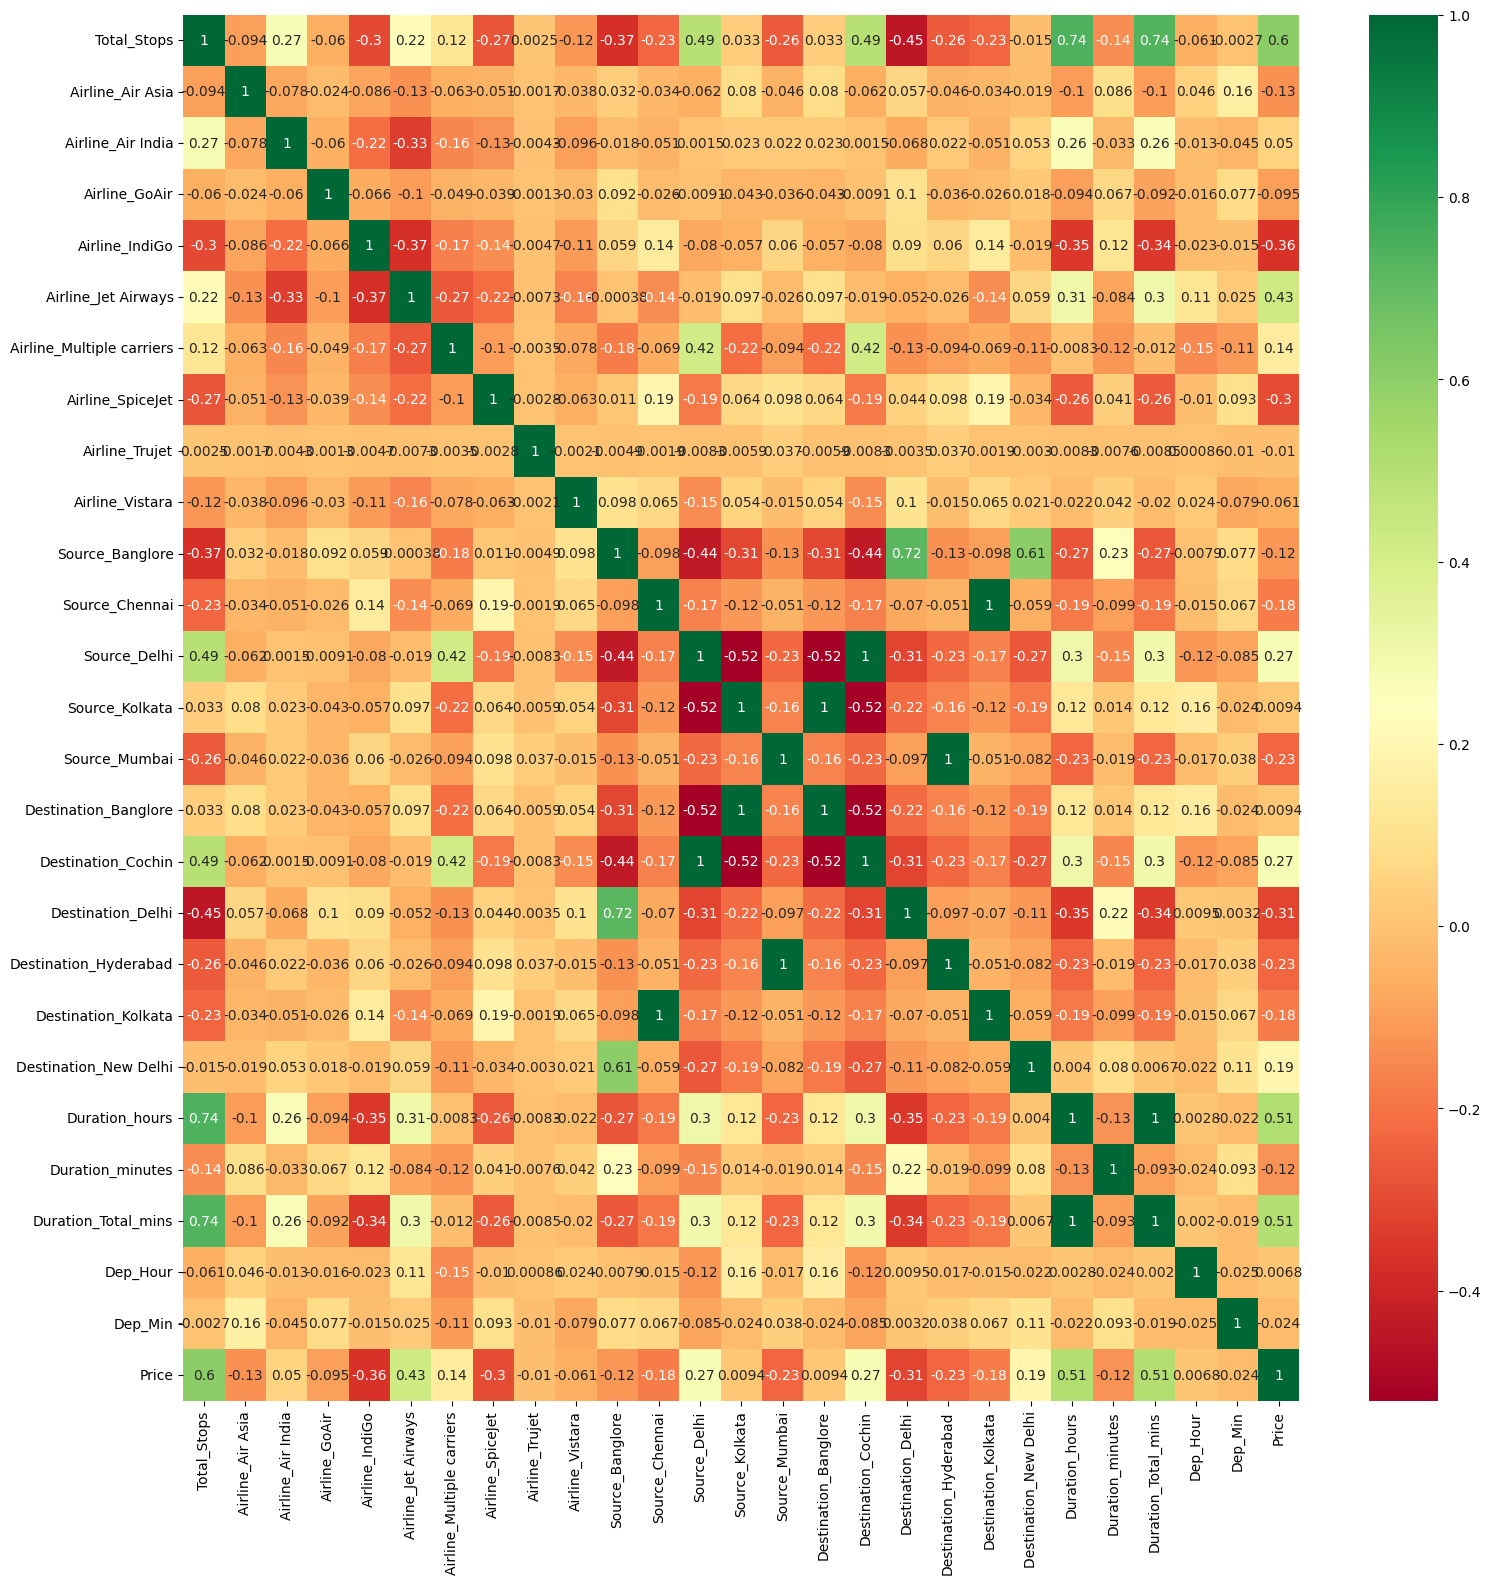

In [32]:
plt.figure(figsize=(18,18))
# Remova as colunas não numéricas antes de calcular a correlação para o mapa de calor
numeric_new_data = new_data.drop(columns=['dep_timezone'], errors='ignore')
sns.heatmap(numeric_new_data.corr(),annot=True,cmap='RdYlGn')

plt.show()

No mapa de calor acima, o verde extremo significa atributos altamente correlacionados positivamente (relação entre duas variáveis em que ambas as variáveis se movem na mesma direção), o vermelho extremo significa atributos correlacionados negativamente (relação entre duas variáveis em que um aumento em uma variável está associado a uma diminuição na outra).


Agora, podemos usar a função `corr()` para calcular e listar a correlação entre todas as variáveis independentes e o 'price'.


In [35]:
numeric_features_data = new_data.drop(columns=['dep_timezone'], errors='ignore')
features = numeric_features_data.corr()['Price'].sort_values()
features

,Price
Airline_IndiGo,-0.361048
Destination_Delhi,-0.313401
Airline_SpiceJet,-0.296552
Source_Mumbai,-0.230745
Destination_Hyderabad,-0.230745
Destination_Kolkata,-0.179216
Source_Chennai,-0.179216
Airline_Air Asia,-0.133044
Duration_minutes,-0.124874
Source_Banglore,-0.118026


Também podemos plotar esses coeficientes de correlação para facilitar a visualização.


<Axes: >

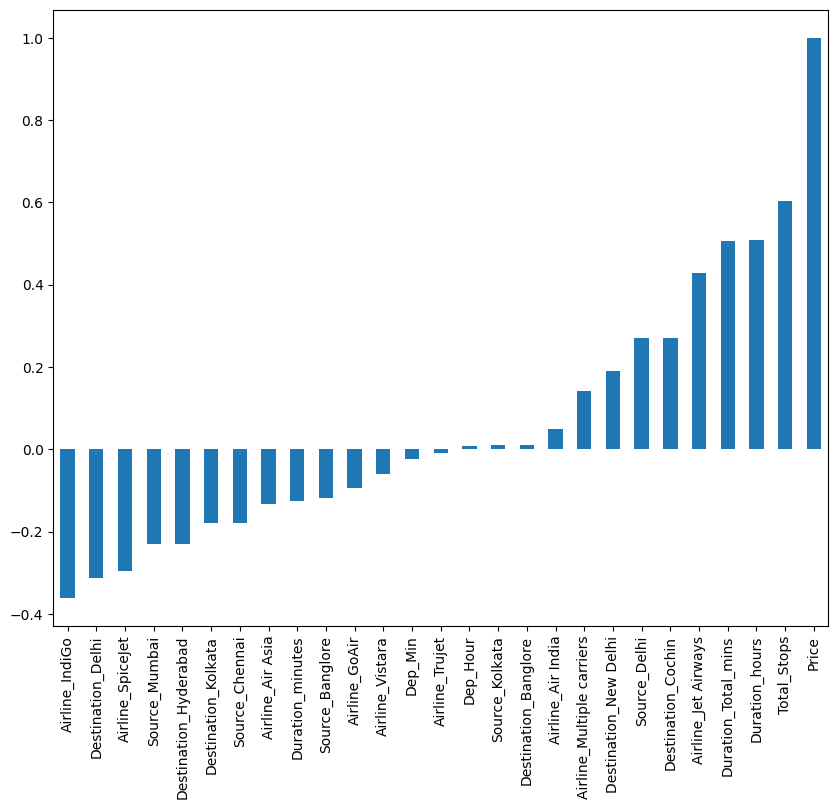

In [36]:
features.plot(kind='bar',figsize=(10,8))

A partir do gráfico acima, podemos deduzir alguns dos atributos altamente correlacionados e selecionar apenas esses para qualquer análise futura.


## **Extração de Atributos usando Análise de Componentes Principais (PCA) (Opcional)**


### **PCA com Scikit-Learn**


A redução de dimensionalidade faz parte do processo de extração de atributos que combina os atributos existentes para produzir novos mais úteis. O objetivo da redução de dimensionalidade é simplificar os dados sem perder muita informação. A Análise de Componentes Principais (PCA) é um dos algoritmos de redução de dimensionalidade mais populares. Primeiro, ele identifica o hiperplano que está mais próximo dos dados e, em seguida, projeta os dados sobre ele. Dessa forma, alguns atributos multidimensionais são fundidos em um só.

Na parte seguinte do laboratório, usaremos a biblioteca `scikit-learn` para realizar algum PCA em nossos dados.
Para saber mais sobre o PCA do `scikit-learn`, visite esta [documentação](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork30654641-2022-01-01#sklearn.decomposition.PCA).


Primeiro, devemos escalonar nossos dados usando a função `StandardScaler()`.
Atribuiremos todas as variáveis independentes a x e a variável dependente, 'price', a y.


In [42]:
x = data1.loc[:,['Total_Stops', 'Airline_Air Asia',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Multiple carriers', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Source_Banglore',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Banglore', 'Destination_Cochin', 'Destination_Delhi',
       'Destination_Hyderabad', 'Destination_Kolkata', 'Destination_New Delhi',
       'Duration_hours', 'Duration_minutes', 'Duration_Total_mins', 'Dep_Hour',
       'Dep_Min']]

In [43]:
y= data1.Price

In [44]:
scaler = StandardScaler()
x=scaler.fit_transform(x.astype(np.float64))
x

array([[-1.22052384, -0.17544122, -0.44291155, ..., -0.93158255,
         1.65425948, -0.23505036],
       [ 1.74150619, -0.17544122,  2.25778713, ..., -0.39007152,
        -1.30309491,  1.36349161],
       [ 1.74150619, -0.17544122, -0.44291155, ...,  0.97847452,
        -0.60724682,  0.0313733 ],
       ...,
       [-1.22052384, -0.17544122, -0.44291155, ..., -0.91189124,
        -0.78120884, -0.23505036],
       [-1.22052384, -0.17544122, -0.44291155, ..., -0.95127386,
        -0.25932278,  0.29779696],
       [ 1.74150619, -0.17544122,  2.25778713, ..., -0.28176932,
        -0.4332848 ,  1.62991527]])

Uma vez que os dados estão escalonados, podemos aplicar a função `fit_transform()` para reduzir a dimensionalidade do conjunto de dados para duas dimensões.


In [45]:
pca = PCA(n_components = 2)
pca.fit_transform(x)

array([[-2.87559235, -0.55520415],
       [ 0.31882945,  2.39235354],
       [ 3.05931822, -0.52686459],
       ...,
       [-2.24752702, -0.58854579],
       [-2.69895755, -0.28856263],
       [ 1.92548188, -1.10426513]])

### **Razão de Variância Explicada**


Outra informação útil no PCA é a razão de variância explicada de cada componente principal, disponível através da função `explained_variance_ratio_`. A razão indica a proporção da variância do conjunto de dados que reside ao longo de cada componente principal. Vamos dar uma olhada na razão de variância explicada de cada um dos nossos dois componentes.


In [46]:
explained_variance=pca.explained_variance_ratio_
explained_variance

array([0.17545521, 0.12110719])

O primeiro componente constitui 17,54% da variância e o segundo componente constitui 12,11% da variância entre os atributos.


## Exercício 6 (Opcional)

Neste exercício, experimente o número de componentes para ver a quantas dimensões nosso conjunto de dados poderia ser reduzido para explicar a maior parte da variabilidade entre os atributos. Além disso, você pode plotar os componentes usando um gráfico de barras para ver quanta variabilidade cada componente representa.


In [50]:
pca = PCA(n_components = 7)
pca.fit_transform(x)
explained_variance=pca.explained_variance_ratio_
explained_variance

array([0.17545521, 0.12110719, 0.0926492 , 0.08280111, 0.06739565,
       0.05275645, 0.04819544])

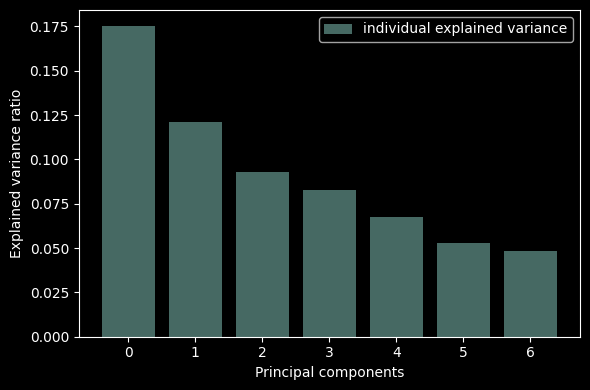

In [51]:
with plt.style.context('dark_background'):

    plt.figure(figsize=(6, 4))

    plt.bar(range(7), explained_variance, alpha=0.5, align='center',
    label='individual explained variance')
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.legend(loc='best')
    plt.tight_layout()

### **Escolhendo o Número Certo de Dimensões**

Em vez de escolher arbitrariamente o número de dimensões para reduzir, é mais simples escolher o número de dimensões que somam uma proporção suficientemente grande da variância, digamos 95%.

O código a seguir realiza o PCA sem reduzir a dimensionalidade e, em seguida, calcula o número mínimo de dimensões necessárias para preservar 95% da variância.


In [52]:
pca = PCA()
pca.fit(x)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >=0.95) + 1

In [53]:
d

np.int64(16)

São necessários 16 componentes para atingir 95% de variância. Portanto, poderíamos definir n_components = 16 e executar o PCA novamente. No entanto, existe uma maneira melhor: em vez de especificar o número de componentes principais que você deseja preservar, você pode definir n_components como um float entre 0,0 e 1,0, indicando a proporção de variância que deseja preservar.


In [54]:
pca = PCA(n_components=0.95)
x_reduced = pca.fit_transform(x)

Existe também uma maneira gráfica de determinar o número de componentes principais em sua análise. É plotar a variância explicada em função do número de dimensões. Geralmente haverá um "cotovelo" na curva, onde a variância explicada para de crescer rapidamente. Esse ponto é geralmente o ponto ideal para o número de componentes principais.


In [55]:
px.area(
    x=range(1, cumsum.shape[0] + 1),
    y=cumsum,
    labels={"x": "# Components", "y": "Explained Variance"}
)